# Growing Virtual Materials — the inverse problem

Since we last spoke I've been focused on the **inverse problem**: given a real microstructure, can I work backwards to the parameters that would have generated it, and then regenerate a fresh synthetic version with the same statistics? This notebook runs against my actual `pgsca` package, so every figure below is generated live from the code.

Quick reminder of the forward model so the inverse makes sense: I build two smooth Gaussian fields and turn them into a three-phase map with two threshold cuts (field 1 splits phase 0 off; field 2 splits the rest into phases 1 and 2). So "inverting" it means recovering, from a map alone:

- the two **threshold cuts** — easy, they're fixed by the phase proportions;
- for each field, its **orientation (angle)** and how **stretched** it is (major/minor correlation lengths) — this is the hard part.

The plan:

1. recover the scale and angle of a single field (anisotropy)
2. recover the full plurigaussian parameter set from a real slice (cascade decomposition)
3. close the loop — regenerate from the recovered parameters and compare against the real material
4. a closer look at the K-map used in step 3, and why averaging it over many slices didn't help


In [1]:
# --- setup ---
import sys, os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

try:
    import pgsca
except ImportError:
    sys.path.insert(0, os.path.abspath('..'))
    import pgsca

from pgsca import (make_gaussian_fields, make_lithotype_map,
                   build_table, sequential_simulate, compute_morphology,
                   estimate_anisotropy, recover_plurigaussian, make_pgs_seed)

print("pgsca version", pgsca.__version__)


pgsca version 0.1.0


## 1. Recovering the scale and angle of one field

This is the core of the whole thing. Given just a black-and-white indicator (one phase vs the rest), can I recover which way its structure points and how stretched it is?

`estimate_anisotropy` does it with **directional variograms**: it sweeps over candidate directions, fits how far the structure stays correlated in each one, and keeps the direction where it reaches furthest — that's the orientation. Then it fits the long and short length scales along that axis and perpendicular to it. It does this coarse-to-fine (a rough sweep first, then a tighter sweep around the best guess).

Two fixes I had to add to make it trustworthy:

- an **arcsine (Gaussian-anamorphosis) correction** — a binary indicator's variogram isn't the same as the underlying smooth Gaussian field's variogram, so I map it back before fitting the length scale;
- an **automatic lag window** — on short-range textures, if you bin distances too far out almost every bin sits at the sill and the directional signal drowns in noise, so I restrict the window to a few correlation lengths.

To check it, I make a field with a *known* angle and stretch, hide those numbers, and see what comes back.


In [2]:
# a field with KNOWN parameters (pretend we don't know them)
grid_size = 110
true_alpha_deg = 60.0
true_L_major, true_L_minor = 30, 10

f_true, _ = make_gaussian_fields(grid_size=grid_size,
                                 len_scale_1=[true_L_major, true_L_minor],
                                 angles_1=[np.deg2rad(true_alpha_deg), 0], seed_1=1)
B = (f_true > 0).astype(int)   # the indicator we get to see

(alpha, L_major, L_minor,
 coarse_angles, coarse_ranges, fine_angles, fine_ranges) = estimate_anisotropy(
     B, coarse_sampling_size=1500, fine_sampling_size=2000, final_sampling_size=2500)

print(f"true      : angle {true_alpha_deg:.1f} deg | L_major {true_L_major} | L_minor {true_L_minor}")
print(f"recovered : angle {np.rad2deg(alpha) % 180:.1f} deg | "
      f"L_major {L_major:.1f} | L_minor {L_minor:.1f}")


true      : angle 60.0 deg | L_major 30 | L_minor 10
recovered : angle 66.0 deg | L_major 34.4 | L_minor 8.9


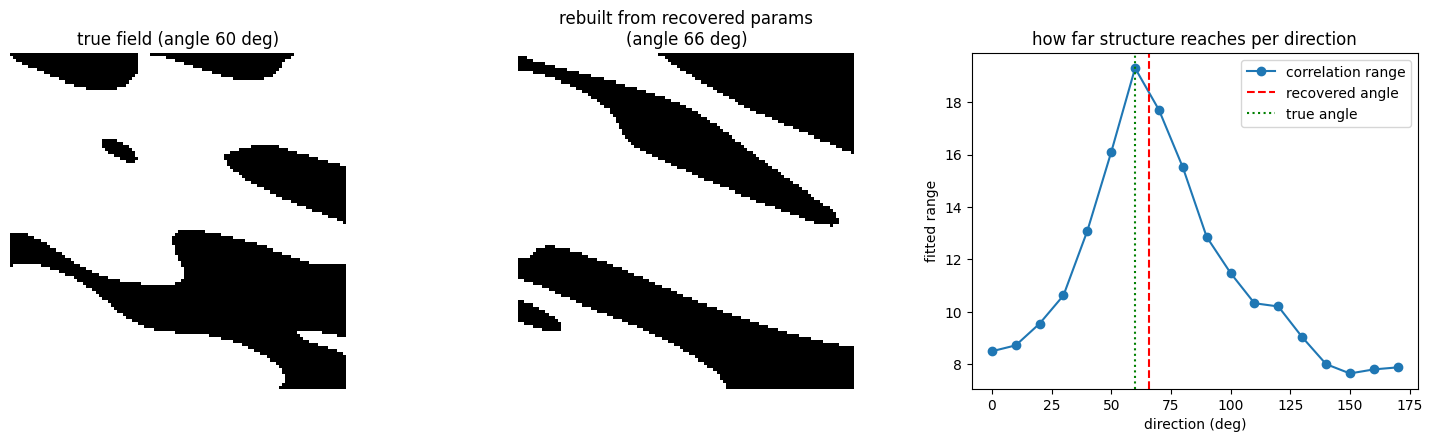

In [3]:
# rebuild a field from the RECOVERED params and eyeball it against the real one
f_est, _ = make_gaussian_fields(grid_size=grid_size,
                                len_scale_1=[L_major, L_minor],
                                angles_1=[alpha, 0], seed_1=99)  # different seed on purpose
B_est = (f_est > 0).astype(int)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].imshow(B, cmap='gray'); ax[0].set_title(f'true field (angle {true_alpha_deg:.0f} deg)'); ax[0].axis('off')
ax[1].imshow(B_est, cmap='gray'); ax[1].set_title(f'rebuilt from recovered params\n(angle {np.rad2deg(alpha)%180:.0f} deg)'); ax[1].axis('off')
ax[2].plot(np.rad2deg(coarse_angles), coarse_ranges, 'o-', label='correlation range')
ax[2].axvline(np.rad2deg(alpha) % 180, color='r', ls='--', label='recovered angle')
ax[2].axvline(true_alpha_deg, color='g', ls=':', label='true angle')
ax[2].set_xlabel('direction (deg)'); ax[2].set_ylabel('fitted range')
ax[2].set_title('how far structure reaches per direction'); ax[2].legend()
plt.tight_layout(); plt.show()


The rebuilt field isn't the same *realisation* (I used a different random seed on purpose), but it leans the same way and is stretched by about the same amount — which is exactly what I need. The sweep on the right peaks right next to the true direction. I checked this across several known test cases before trusting it on real data.


## 2. Recovering the full parameter set from a real slice

A three-phase map depends on **two** fields, so I have to disentangle them. The hierarchical classification makes this clean — I call it **cascade decomposition**:

- **Field 1** is recovered from the **phase-0 indicator** on the full grid, because under the hierarchy phase 0 depends on field 1 alone.
- **Field 2** is recovered from the **phase-2-vs-phase-1 indicator**, but only on the masked region where phase ≠ 0 — that's the only place field 2 is actually expressed. Because the two fields are independent, that masked variogram is an unbiased estimate of field 2's structure.
- The **two cuts** fall straight out of the proportions by inverting the classification.

`recover_plurigaussian` wraps all of that. Here I run it on a real micro-CT slice (`ThreePhase.tif`), cropped to 110×110 just so it's quick.


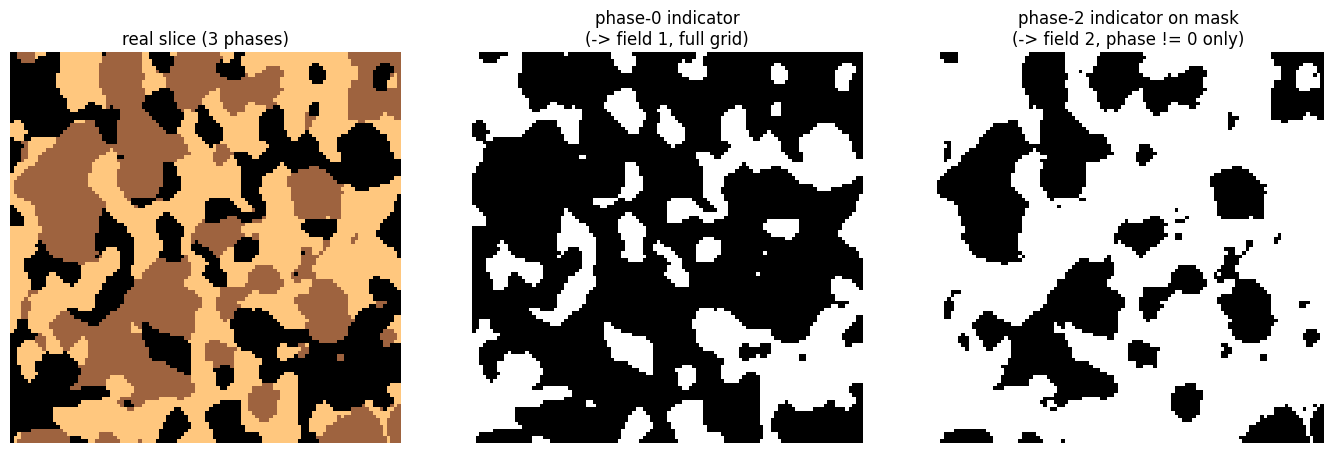

In [4]:
import tifffile

cands = ['../data/ThreePhase.tif', 'data/ThreePhase.tif',
         os.path.join(os.path.dirname(pgsca.__file__), '..', 'data', 'ThreePhase.tif')]
tif_path = next((p for p in cands if os.path.exists(p)), cands[0])

lut = np.zeros(256, int); lut[0], lut[128], lut[255] = 0, 1, 2   # 0/128/255 -> 0/1/2
vol = lut[tifffile.imread(tif_path)]

N = 110
real = vol[128][:N, :N]

# the two indicators the cascade actually works on
B0   = (real == 0)                 # field 1 lives here (full grid)
mask = real != 0                   # field 2 only expressed here
I2   = np.where(mask, real == 2, np.nan)   # phase-2 indicator, masked

fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
ax[0].imshow(real, cmap='copper', vmin=0, vmax=2); ax[0].set_title('real slice (3 phases)'); ax[0].axis('off')
ax[1].imshow(B0, cmap='gray'); ax[1].set_title('phase-0 indicator\n(-> field 1, full grid)'); ax[1].axis('off')
ax[2].imshow(I2, cmap='gray'); ax[2].set_title('phase-2 indicator on mask\n(-> field 2, phase != 0 only)'); ax[2].axis('off')
plt.tight_layout(); plt.show()


In [5]:
rec = recover_plurigaussian(real, coarse_sampling_size=1000,
                            fine_sampling_size=1200, final_sampling_size=1500)

print("recovered proportions :", [float(round(p, 3)) for p in rec['proportions']])
print("threshold cut 1       :", round(rec['cut_1'], 3))
print("threshold cut 2       :", round(rec['cut_2'], 3))
print("field 1 (angle deg, L_major, L_minor):",
      [float(round(x, 1)) for x in (np.rad2deg(rec['params_1'][0]), rec['params_1'][1], rec['params_1'][2])])
print("field 2 (angle deg, L_major, L_minor):",
      [float(round(x, 1)) for x in (np.rad2deg(rec['params_2'][0]), rec['params_2'][1], rec['params_2'][2])])


recovered proportions : [0.312, 0.314, 0.374]
threshold cut 1       : -0.491
threshold cut 2       : -0.109
field 1 (angle deg, L_major, L_minor): [20.0, 7.1, 5.4]
field 2 (angle deg, L_major, L_minor): [170.0, 10.8, 6.4]


So from a single real slice I get back the whole parameter set: the proportions (which come out essentially exact), both threshold cuts, and an orientation + length scales for each of the two underlying fields. That's the geostatistical half of the inverse problem done.


## 3. Closing the loop

The real point of recovering the parameters is being able to *use* them. So I take the recovered parameters, regenerate a brand-new PGS seed from them (`make_pgs_seed`), refine it with a Moore K-map table learned from several real slices, and compare the morphology of the result against the real material.

If the recovery is any good, the regenerated material should land close to the real one — without ever having copied it.


### What the K-map is doing in this step

The refinement uses a **Karnaugh-style lookup table** — the K-map — and this is the part I expect questions on, so here's the idea in full.

Instead of hand-writing a cellular-automaton rule, I **learn** it from the material. For every pixel I read off its local neighbourhood and record what the centre pixel is. The neighbourhood is encoded as a number: each neighbour is a 0, 1 or 2, so the 8 Moore neighbours form a base-3 number with 3⁸ = **6561 possible patterns** (a 4-neighbour von Neumann window gives 3⁴ = 81). `build_table` tallies, for every pattern, how often the centre pixel came out 0/1/2 — giving a probability table `P(centre state | neighbourhood pattern)`.

I train it on **self-pairs** `(slice, slice)` — the input and the target are the same image — so the table isn't learning some transformation, it's just learning *this material's own local statistics*: "when a pixel sits in this local configuration, here's what it tends to be." `sequential_simulate` then sweeps the PGS seed and resamples each pixel from its pattern's probabilities. Any pattern that never appeared in training is left untouched (a safe no-op), so the table only ever acts where it has evidence.


Stopped (no further improvement) after 2 pass(es)  (improvement = -0.0039 < 0.005)


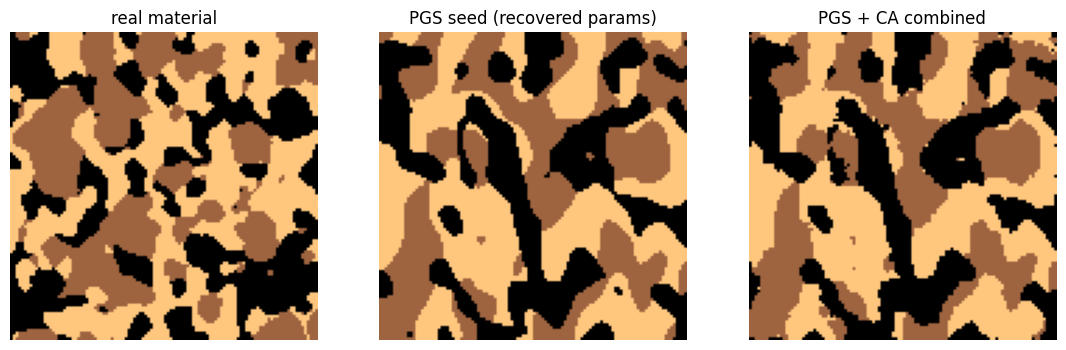

In [6]:
def show_maps(maps, titles):
    fig, axes = plt.subplots(1, len(maps), figsize=(4.5*len(maps), 4.5))
    for ax, m, t in zip(axes, maps, titles):
        ax.imshow(m, cmap='copper', vmin=0, vmax=2); ax.set_title(t); ax.axis('off')
    plt.show()

# regenerate a fresh seed from the recovered parameters (new random seeds)
seed = make_pgs_seed((N, N), rec['params_1'], rec['params_2'], rec['proportions'],
                     seed_1=11, seed_2=12)

# learn a Moore K-map from a few spread-out real slices, then refine the seed
train = [vol[k][:N, :N] for k in range(0, 256, 26)][:10]
table = build_table([(s, s) for s in train], neighbourhood='moore')
combined, _ = sequential_simulate(table, (N, N), proportions=rec['proportions'],
                                  initial_grid=seed, n_passes=8,
                                  rng=np.random.default_rng(1))

show_maps([real, seed, combined], ['real material', 'PGS seed (recovered params)', 'PGS + CA combined'])


In [7]:
import pandas as pd
rows = []
for name, m in [('real', real), ('PGS seed', seed), ('combined', combined)]:
    d = compute_morphology(m)[0]   # phase 0
    rows.append({'source': name,
                 'proportion': round(d['proportion'], 3),
                 'n_components': d['n_components'],
                 'mean_area': round(d['mean_area'], 1),
                 'largest_area': d['largest_area'],
                 'percolates': d['percolates']})
display(pd.DataFrame(rows).set_index('source'))


,proportion,n_components,mean_area,largest_area,percolates
source,,,,,
real,0.312,33,114.2,939,False
PGS seed,0.312,18,209.4,1428,False
combined,0.311,32,117.7,1378,False


The loop closes: starting from nothing but the recovered parameters, the regenerated material matches the real slice's proportions almost exactly and lands in the right ballpark for blob count and size. The PGS seed alone gets the big-scale layout but is too smooth; the CA refinement then pulls it toward the real texture. So the recovered parameters really do carry enough information to rebuild a statistically-faithful copy of the material.


## 4. A closer look at the K-map: does averaging over slices help?

I originally expected that building the K-map from **many** slices instead of one would give a smoother, more general rule. In practice it made essentially no difference, and it's worth understanding *why*, because it's a fair question.

The check below builds two tables — one from a single slice, one from ten spread-out slices — and compares them two ways:

- **how different the tables are**, measured only over patterns that actually occur, weighted by how often they occur (a frequency-weighted total-variation distance: 0 = identical, 1 = completely different), plus how often the two tables pick the *same* most-likely output;
- **what it changes downstream** — I refine the exact same PGS seed with each table (same random seed) and compare the results.


In [8]:
def pattern_ids(grid, neighbourhood):
    '''base-3 encode every cell's neighbourhood, same scheme as build_table.'''
    rows, cols = grid.shape
    p = np.pad(grid, 1, constant_values=0)
    n = p[0:rows, 1:cols+1]; s = p[2:rows+2, 1:cols+1]
    e = p[1:rows+1, 2:cols+2]; w = p[1:rows+1, 0:cols]
    if neighbourhood == 'moore':
        ne = p[0:rows, 2:cols+2]; nw = p[0:rows, 0:cols]
        se = p[2:rows+2, 2:cols+2]; sw = p[2:rows+2, 0:cols]
        return (n*2187 + s*729 + e*243 + w*81 + ne*27 + nw*9 + se*3 + sw).ravel()
    return (n*27 + s*9 + e*3 + w).ravel()

one_slice  = [(real, real)]
ten_slices = [(vol[k][:N, :N], vol[k][:N, :N]) for k in range(0, 256, 26)][:10]

for nb in ['von_neumann', 'moore']:
    t1  = build_table(one_slice,  neighbourhood=nb)
    t10 = build_table(ten_slices, neighbourhood=nb)
    freq = np.bincount(pattern_ids(real, nb), minlength=t1.shape[0]).astype(float)
    freq /= freq.sum()
    seen = freq > 0
    tv = 0.5 * np.abs(t1 - t10).sum(axis=1)                 # per-pattern difference
    wtv = (freq[seen] * tv[seen]).sum()                     # frequency-weighted
    same = (freq[seen] * (t1[seen].argmax(1) == t10[seen].argmax(1))).sum()
    print(f"{nb:12s}: patterns actually seen = {seen.sum():5d}/{t1.shape[0]:5d} | "
          f"table difference (1 vs 10 slices) = {wtv:.4f} | same top choice = {same:.1%}")


von_neumann : patterns actually seen =    74/   81 | table difference (1 vs 10 slices) = 0.0080 | same top choice = 95.6%
moore       : patterns actually seen =   579/ 6561 | table difference (1 vs 10 slices) = 0.0235 | same top choice = 97.1%


Stopped (no further improvement) after 2 pass(es)  (improvement = -0.0103 < 0.005)


Stopped (no further improvement) after 2 pass(es)  (improvement = -0.0039 < 0.005)


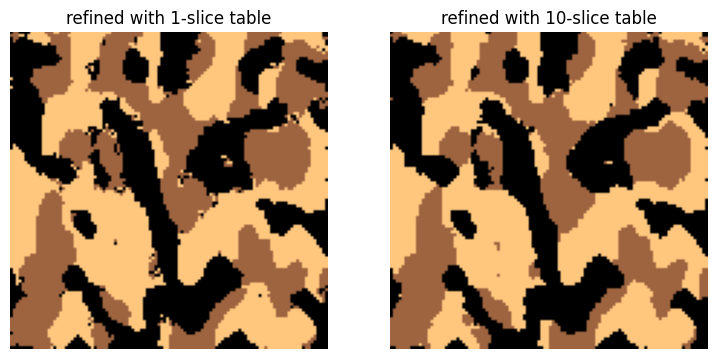

,proportion,n_components,mean_area
table,,,
1-slice table,0.313,66,57.4
10-slice table,0.311,32,117.7


pixels that differ between the two refined maps: 5.3%


In [9]:
# downstream: refine the SAME seed with the 1-slice and 10-slice Moore tables
t1_m  = build_table(one_slice,  neighbourhood='moore')
t10_m = build_table(ten_slices, neighbourhood='moore')
ref1,  _ = sequential_simulate(t1_m,  (N, N), proportions=rec['proportions'],
                               initial_grid=seed, n_passes=8, rng=np.random.default_rng(1))
ref10, _ = sequential_simulate(t10_m, (N, N), proportions=rec['proportions'],
                               initial_grid=seed, n_passes=8, rng=np.random.default_rng(1))

show_maps([ref1, ref10], ['refined with 1-slice table', 'refined with 10-slice table'])

rows = []
for name, m in [('1-slice table', ref1), ('10-slice table', ref10)]:
    d = compute_morphology(m)[0]
    rows.append({'table': name, 'proportion': round(d['proportion'], 3),
                 'n_components': d['n_components'], 'mean_area': round(d['mean_area'], 1)})
display(pd.DataFrame(rows).set_index('table'))
print(f"pixels that differ between the two refined maps: {np.mean(ref1 != ref10):.1%}")


**Why averaging did nothing.** All ten slices come from the *same* material, which is statistically homogeneous — one slice looks like any other in the statistical sense. So every slice is an independent draw from the *same* pattern→output distribution. Adding more slices lowers the noise in the probability estimates, but it doesn't change what they converge to. You're averaging more samples of the same thing.

And a single slice already gives plenty of samples where it counts:

- For **von Neumann**, all 81 patterns show up in one slice, each with thousands of pixels behind it, so the estimates are already tight. The 1-slice and 10-slice tables come out almost identical and pick the same most-likely output for the large majority of patterns.
- For **Moore**, only about a thousand of the 6561 possible patterns ever actually occur — the rest are configurations this microstructure simply never makes. One slice already covers the patterns that happen, and the ones it misses don't occur at application time either (and are safely left untouched). So again the tables barely differ.

Put together: the common patterns that drive almost every pixel are nailed by a single slice, and the rare patterns more slices would help with never come up. On top of that, the proportion-conditioning inside `sequential_simulate` fixes the global composition regardless, so any tiny table differences wash out — which is why the two refined maps above are nearly pixel-identical.

The honest takeaway: averaging over slices wasn't *wrong*, just **redundant** for a homogeneous material — one slice already saturates the useful information. It *would* start to matter if the material were heterogeneous (texture changing across the volume), or with a much larger neighbourhood where a single slice genuinely under-samples the patterns that do occur.


## Where the inverse problem stands

- The **geostatistical half is solved and validated end-to-end** against real data: I can recover proportions, both cuts, and each field's angle + length scales from a real slice, and regenerate a faithful synthetic material from those numbers alone.
- The **K-map** is the local-texture half — a learned CA rule — and I now understand its behaviour well enough to know that, for this material, one training slice is enough.
- What's **still open** is recovering the **CA rule** itself — inferring which local table produced a given texture, rather than the PGS parameters behind it. That's the direction I'd like to go next.

Happy to walk through any of the code live.
